# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [49]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [50]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [51]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [52]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [53]:
from sklearn.model_selection import train_test_split

seed = 1 

X = data.drop('MEDV', axis=1)
y = data['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                                         
    test_size = 0.2, 
    shuffle = True,
    random_state = seed
)

## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

## 3. Calculate and print R-squared for both the training and the testing set.

In [55]:
r2_test = model.score(X_test, y_test)
r2_train = model.score(X_train, y_train)

print(f"R-squared for the training set: {r2_train:.4f}")
print(f"R-squared for the testing set: {r2_test:.4f}")


R-squared for the training set: 0.7294
R-squared for the testing set: 0.7634


## 4. Calculate and print mean squared error for both the training and the testing set.

In [57]:
from sklearn.metrics import mean_squared_error

mse_test = mean_squared_error(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Mean square error for test: {mse_test:.4f}")
print(f"Mean square error for train: {mse_train:.4f}")


Mean square error for test: 23.3808
Mean square error for train: 21.8628


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [58]:
import numpy as np

mae_test = np.sqrt(mse_test)
mae_train = np.sqrt(mse_train)

print(f"Mean absolute error for test: {mae_test:.4f}")
print(f"Mean absolute error for train: {mae_train:.4f}")

Mean absolute error for test: 4.8354
Mean absolute error for train: 4.6758


## Classification Model Evaluation

In [59]:
from sklearn.datasets import load_iris
data = load_iris()

In [60]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [61]:
column_names = data.feature_names

In [62]:
df = pd.DataFrame(data['data'],columns=column_names)

In [63]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [64]:
target = pd.DataFrame(data.target)

In [65]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [66]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(df, target,
                                                    test_size = 0.2,
                                                    random_state =seed,
                                                    stratify = target
                                                   )
print("Training:", X_train.shape)
print("Test:", X_test.shape)
print("Total:", df.shape)

Training: (120, 4)
Test: (30, 4)
Total: (150, 4)


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [68]:
from sklearn.linear_model import SGDClassifier  # Regresión Logística (SGD)
from sklearn.preprocessing import StandardScaler  # IMPORTANTE para SGD!

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_rl = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.01,
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    verbose=0,
    random_state=seed
    )

modelo_rl.fit(X_train_scaled, y_train)

y_train_pred = modelo_rl.predict(X_train_scaled)
y_test_pred = modelo_rl.predict(X_test_scaled)

## 8. Calculate and print the accuracy score for both the training and the testing set.

In [69]:
accuracy_train = modelo_rl.score(X_train_scaled, y_train_pred)
accuracy_test = modelo_rl.score(X_test_scaled, y_test)

print(f"Accuracy train: {accuracy_train:.2%}")
print(f"Accuracy test: {accuracy_test:.2%}")

Accuracy train: 100.00%
Accuracy test: 90.00%


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [70]:

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_test = accuracy_score(y_test, y_test_pred)
accuracy_train = accuracy_score(y_train, y_train_pred)

print(f"Accuracy test for Test: {accuracy_test:.2f}")
print(f"Accuracy test for Train: {accuracy_train:.2f}")

Accuracy test for Test: 0.90
Accuracy test for Train: 0.91


## 10. Calculate and print the precision score for both the training and the testing set.

In [71]:
precision_test = precision_score(y_test, y_test_pred, pos_label= 0, average='macro')
precision_train = precision_score(y_train, y_train_pred, pos_label= 0, average='macro')

print(f"Precision Test Set: {precision_test*100:.2f}%")
print(f"Precision Train Set: {precision_train*100:.2f}%")

Precision Test Set: 90.24%
Precision Train Set: 91.22%


## 11. Calculate and print the recall score for both the training and the testing set.

In [72]:
recall_test = recall_score(y_test, y_test_pred, pos_label=0, average='macro')
recall_train = recall_score(y_train, y_train_pred, pos_label=0, average='macro')

print(f"Recall test set: {recall_test*100:.2f}%")
print(f"Recall test set: {recall_train*100:.2f}%")

Recall test set: 90.00%
Recall test set: 90.83%


## 12. Calculate and print the F1 score for both the training and the testing set.

In [73]:
f1_train = fbeta_score(y_train, y_train_pred, beta=1, pos_label=0, average='macro')
f1_test = fbeta_score(y_test, y_test_pred, beta=1, pos_label=0, average='macro')

print(f"F1-SCORE for train set: {f1_train*100:.2f}%")
print(f"F1-SCORE for test set: {f1_test*100:.2f}%")

F1-SCORE for train set: 90.80%
F1-SCORE for test set: 89.97%


## 13. Generate confusion matrices for both the training and the testing set.

Confusion Matrix for Test set:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Confusion Matrix for Train set:
[[40  0  0]
 [ 0 32  8]
 [ 0  3 37]]


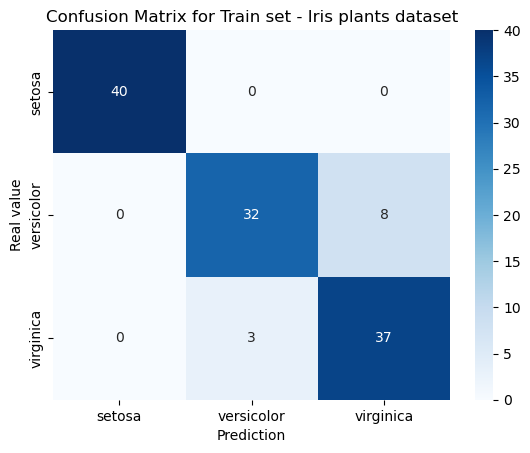

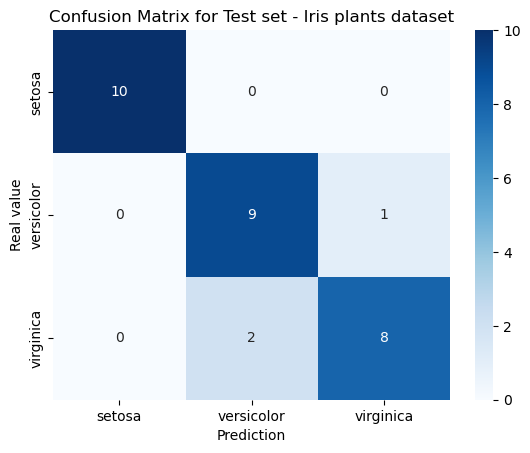

In [74]:
cm_test = confusion_matrix(y_test, y_test_pred)
cm_train = confusion_matrix(y_train, y_train_pred)

print(f"Confusion Matrix for Test set:")
print(cm_test)
print(f"Confusion Matrix for Train set:")
print(cm_train)


sns.heatmap(cm_train,
            annot=True,
            cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)


plt.title('Confusion Matrix for Train set - Iris plants dataset')
plt.ylabel('Real value')
plt.xlabel('Prediction')
plt.show()


sns.heatmap(cm_test,
            annot=True,
            cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)


plt.title('Confusion Matrix for Test set - Iris plants dataset')
plt.ylabel('Real value')
plt.xlabel('Prediction')
plt.show()


## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [75]:
#Housing Data set

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor        
from sklearn.preprocessing import StandardScaler     
from sklearn.preprocessing import PolynomialFeatures 

#Load data
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

X_house = data.drop('MEDV', axis=1)
y_house = data['MEDV']

#Train/test division
X_train, X_test, y_train, y_test = train_test_split(
    X_house, y_house,                                         
    test_size = 0.2, 
    shuffle = True,
    random_state = seed
)


# Polynomic features creation 
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#Scale features (Estandarización)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly) 
X_test_poly_scaled = scaler.transform(X_test_poly)    

# Model SGD
sgd_model = SGDRegressor(
    loss='squared_error',      # Función de pérdida = MSE
    penalty=None,              # SIN regularización
    eta0=0.0001,               # Learning rate (tasa de aprendizaje BAJA!)
    learning_rate='constant',  # Learning rate constante
    max_iter=1000,             # Número máximo de iteraciones (epochs)
    tol=1e-3,                  # Tolerancia para detener si converge
    random_state=seed,         # Semilla activada para reproducibilidad
    verbose=0                  # No mostrar progreso
)

sgd_model.fit(X_train_poly_scaled, y_train) 
y_train_pred = sgd_model.predict(X_train_poly_scaled) 
y_test_pred = sgd_model.predict(X_test_poly_scaled) 
 
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)    
r2_test = r2_score(y_test, y_test_pred) 

print(f"MSE (train): {mse_train:.4f}")
print(f"MSE (test):  {mse_test:.4f}")
print(f"RMSE (train): {np.sqrt(mse_train):.4f}")
print(f"RMSE (test):  {np.sqrt(mse_test):.4f}")
print(f"R² (train):  {r2_train:.4f}")
print(f"R² (test):   {r2_test:.4f}")

#Comparission with the previous model
# MSE for test: 23.38
# MSE for train: 21.86
# RMSE test: 4.83
# RMSE train: 4.67
# R-squared for the training set: 0.72
# R-squared for the testing set: 0.76

# In conclusion we can say that this model is better for the Housing Data set.

MSE (train): 13.3428
MSE (test):  12.5288
RMSE (train): 3.6528
RMSE (test):  3.5396
R² (train):  0.8348
R² (test):   0.8732


In [80]:
# Iris data set
from sklearn.neighbors import KNeighborsClassifier
seed = 1

df_iris = load_iris()

X_iris = pd.DataFrame(df_iris.data, columns=df_iris.feature_names)
y_iris = pd.Series(df_iris.target, name='species')


#Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, 
    test_size=0.2, 
    random_state=seed,
    stratify=y_iris
)

#Scaler - ESSENTIAL FOR KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#model KNN
model_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

#train model
model_knn.fit(X_train_scaled, y_train)

#predict
y_train_pred = model_knn.predict(X_train_scaled)
y_test_pred = model_knn.predict(X_test_scaled)

#Evaluate

accuracy_test = accuracy_score(y_test, y_test_pred)
accuracy_train = accuracy_score(y_train, y_train_pred)

print(f"Accuracy test set: {accuracy_test*100:.2f}")
print(f"Accuracy train set: {accuracy_train*100:.2f}")
print()

cm_knn_test = confusion_matrix(y_test, y_test_pred)
cm_knn_train = confusion_matrix(y_train, y_train_pred)
print(f"Confusion matrix test set:")
print(cm_knn_test)
print()

print(f"Confusion matrix train set:")
print(cm_knn_train)


Accuracy test set: 96.67
Accuracy train set: 100.00

Confusion matrix test set:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Confusion matrix train set:
[[40  0  0]
 [ 0 40  0]
 [ 0  0 40]]


Compared to the results of the previous model used for the Iris da set we can see that the KNN model is better for analyse this data set 

Confusion Matrix for Test set:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Confusion Matrix for Train set:
[[40  0  0]
 [ 0 32  8]
 [ 0  3 37]]